# Classification
---


В данном ноутбуке библиотеки будут импортироваться по мере необходимости, что продиктовано удобством для процесса обучения. Однако напоминаю, что лучше, если все импорты у вас находятся в одной ячейке!

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Данные

Набор данных по диагностике диабета.

Этот набор данных содержит 9538 медицинских записей , связанных с диагностикой диабета и факторами риска. Он включает различные параметры здоровья, привычки образа жизни и генетические предрасположенности, которые способствуют риску диабета. Данные структурированы с реалистичными распределениями, что делает их ценными для медицинских исследований, статистического анализа и приложений машинного обучения.

---
Описание столбцов:

- Age: The age of the individual (18-90 years).
- Pregnancies: Number of times the patient has been pregnant.
- BMI (Body Mass Index): A measure of body fat based on height and weight (kg/m²).
- Glucose: Blood glucose concentration (mg/dL), a key diabetes indicator.
- BloodPressure: Systolic blood pressure (mmHg), higher levels may indicate hypertension.
- HbA1c: Hemoglobin A1c level (%), representing average blood sugar over months.
- LDL (Low-Density Lipoprotein): "Bad" cholesterol level (mg/dL).
- HDL (High-Density Lipoprotein): "Good" cholesterol level (mg/dL).
- Triglycerides: Fat levels in the blood (mg/dL), high values increase diabetes risk.
- WaistCircumference: Waist measurement (cm), an indicator of central obesity.
- HipCircumference: Hip measurement (cm), used to calculate WHR.
- WHR (Waist-to-Hip Ratio): Waist circumference divided by hip circumference.
- FamilyHistory: Indicates if the individual has a family history of diabetes (1 = Yes, 0 = No).
- DietType: Dietary habits (0 = Unbalanced, 1 = Balanced, 2 = Vegan/Vegetarian).
- Hypertension: Presence of high blood pressure (1 = Yes, 0 = No).
- MedicationUse: Indicates if the individual is taking medication (1 = Yes, 0 = No).
- Outcome: Diabetes diagnosis result (1 = Diabetes, 0 = No Diabetes).

---
Этот набор данных полезен для изучения взаимосвязей между образом жизни, генетическими факторами и риском развития диабета, предоставляя ценную информацию для прогностического моделирования и аналитики здоровья.

In [10]:
df = pd.read_csv('diabetes_dataset.csv')

In [11]:
df.head()

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
0,69,5,28.39,130.1,77.0,5.4,130.4,44.0,50.0,90.5,107.9,0.84,0,0,0,1,0
1,32,1,26.49,116.5,72.0,4.5,87.4,54.2,129.9,113.3,81.4,1.39,0,0,0,0,0
2,89,13,25.34,101.0,82.0,4.9,112.5,56.8,177.6,84.7,107.2,0.79,0,0,0,1,0
3,78,13,29.91,146.0,104.0,5.7,50.7,39.1,117.0,108.9,110.0,0.99,0,0,0,1,1
4,38,8,24.56,103.2,74.0,4.7,102.5,29.1,145.9,84.1,92.8,0.91,0,1,0,0,0


Ознакомьтесь с данными, проверьте их на наличие ошибок, пропусков и прочих вещей, которые могут осложнить дальнейшую работу. Ознакомьтесь с типами данных в таблице.

In [12]:
# Ваш код
df.describe()

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
count,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000
mean,53.577584,7.986161,27.052364,106.104183,84.475781,4.650661,100.133456,49.953418,151.147746,93.951678,103.060621,0.917400,0.302474,0.486161,0.001048,0.405012,0.344097
std,20.764651,4.933469,5.927955,21.918590,14.123480,0.476395,29.911910,15.242194,48.951627,15.594468,13.438827,0.140828,0.459354,0.661139,0.032364,0.490920,0.475098
min,18.000000,0.000000,15.000000,50.000000,60.000000,4.000000,-12.000000,-9.200000,50.000000,40.300000,54.800000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,4.000000,22.870000,91.000000,74.000000,4.300000,80.100000,39.700000,117.200000,83.400000,94.000000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,8.000000,27.050000,106.000000,84.000000,4.600000,99.900000,50.200000,150.550000,93.800000,103.200000,0.910000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,12.000000,31.180000,121.000000,94.000000,5.000000,120.200000,60.200000,185.100000,104.600000,112.100000,1.010000,1.000000,1.000000,0.000000,1.000000,1.000000
max,89.000000,16.000000,49.660000,207.200000,138.000000,6.900000,202.200000,107.800000,345.800000,163.000000,156.600000,1.490000,1.000000,2.000000,1.000000,1.000000,1.000000


In [17]:
display(df[(df['LDL'] < 0)])
df[(df['HDL'] < 0)]

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
448,30,13,17.93,82.6,64.0,4.3,-1.8,58.0,157.0,96.1,96.4,1.00,1,0,0,0,1
1332,34,7,30.66,114.4,69.0,4.4,-7.4,31.3,134.0,121.5,110.0,1.10,1,0,0,0,1
1437,89,16,27.02,115.0,94.0,4.9,-12.0,61.0,151.3,98.8,100.7,0.98,0,1,0,1,0
5344,81,5,22.81,123.7,92.0,5.2,-1.5,47.1,146.9,100.3,82.9,1.21,0,1,0,1,0
8478,86,4,18.08,76.1,91.0,4.0,-0.5,64.3,188.3,82.6,81.9,1.01,0,1,0,1,0


,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
3940,58,12,33.73,119.5,91.0,4.5,85.3,-0.3,85.8,98.2,98.5,1.00,0,1,0,0,0
5405,82,5,27.89,126.5,86.0,4.7,152.7,-0.3,178.3,108.9,100.7,1.08,0,0,0,1,0
5660,61,16,27.71,115.0,96.0,4.9,81.6,-0.9,101.1,97.2,103.0,0.94,0,0,0,1,0
6102,76,8,21.19,93.8,73.0,4.0,104.9,-2.2,92.5,79.3,112.7,0.70,0,0,0,1,0
6210,84,3,32.28,139.5,97.0,5.4,100.4,-3.0,127.4,98.4,112.6,0.87,0,1,0,1,0
8677,84,2,28.32,117.5,90.0,4.5,48.5,-9.2,208.5,100.7,135.1,0.75,0,0,0,1,0


In [20]:
df[['LDL', 'HDL']] = abs(df[['LDL', 'HDL']])
df.describe()

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
count,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000
mean,53.577584,7.986161,27.052364,106.104183,84.475781,4.650661,100.138320,49.956752,151.147746,93.951678,103.060621,0.917400,0.302474,0.486161,0.001048,0.405012,0.344097
std,20.764651,4.933469,5.927955,21.918590,14.123480,0.476395,29.895618,15.231261,48.951627,15.594468,13.438827,0.140828,0.459354,0.661139,0.032364,0.490920,0.475098
min,18.000000,0.000000,15.000000,50.000000,60.000000,4.000000,0.300000,0.000000,50.000000,40.300000,54.800000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,4.000000,22.870000,91.000000,74.000000,4.300000,80.100000,39.700000,117.200000,83.400000,94.000000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,8.000000,27.050000,106.000000,84.000000,4.600000,99.900000,50.200000,150.550000,93.800000,103.200000,0.910000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,12.000000,31.180000,121.000000,94.000000,5.000000,120.200000,60.200000,185.100000,104.600000,112.100000,1.010000,1.000000,1.000000,0.000000,1.000000,1.000000
max,89.000000,16.000000,49.660000,207.200000,138.000000,6.900000,202.200000,107.800000,345.800000,163.000000,156.600000,1.490000,1.000000,2.000000,1.000000,1.000000,1.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9538 entries, 0 to 9537
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 9538 non-null   int64  
 1   Pregnancies         9538 non-null   int64  
 2   BMI                 9538 non-null   float64
 3   Glucose             9538 non-null   float64
 4   BloodPressure       9538 non-null   float64
 5   HbA1c               9538 non-null   float64
 6   LDL                 9538 non-null   float64
 7   HDL                 9538 non-null   float64
 8   Triglycerides       9538 non-null   float64
 9   WaistCircumference  9538 non-null   float64
 10  HipCircumference    9538 non-null   float64
 11  WHR                 9538 non-null   float64
 12  FamilyHistory       9538 non-null   int64  
 13  DietType            9538 non-null   int64  
 14  Hypertension        9538 non-null   int64  
 15  MedicationUse       9538 non-null   int64  
 16  Outcome          

In [7]:
df.shape

(9538, 17)

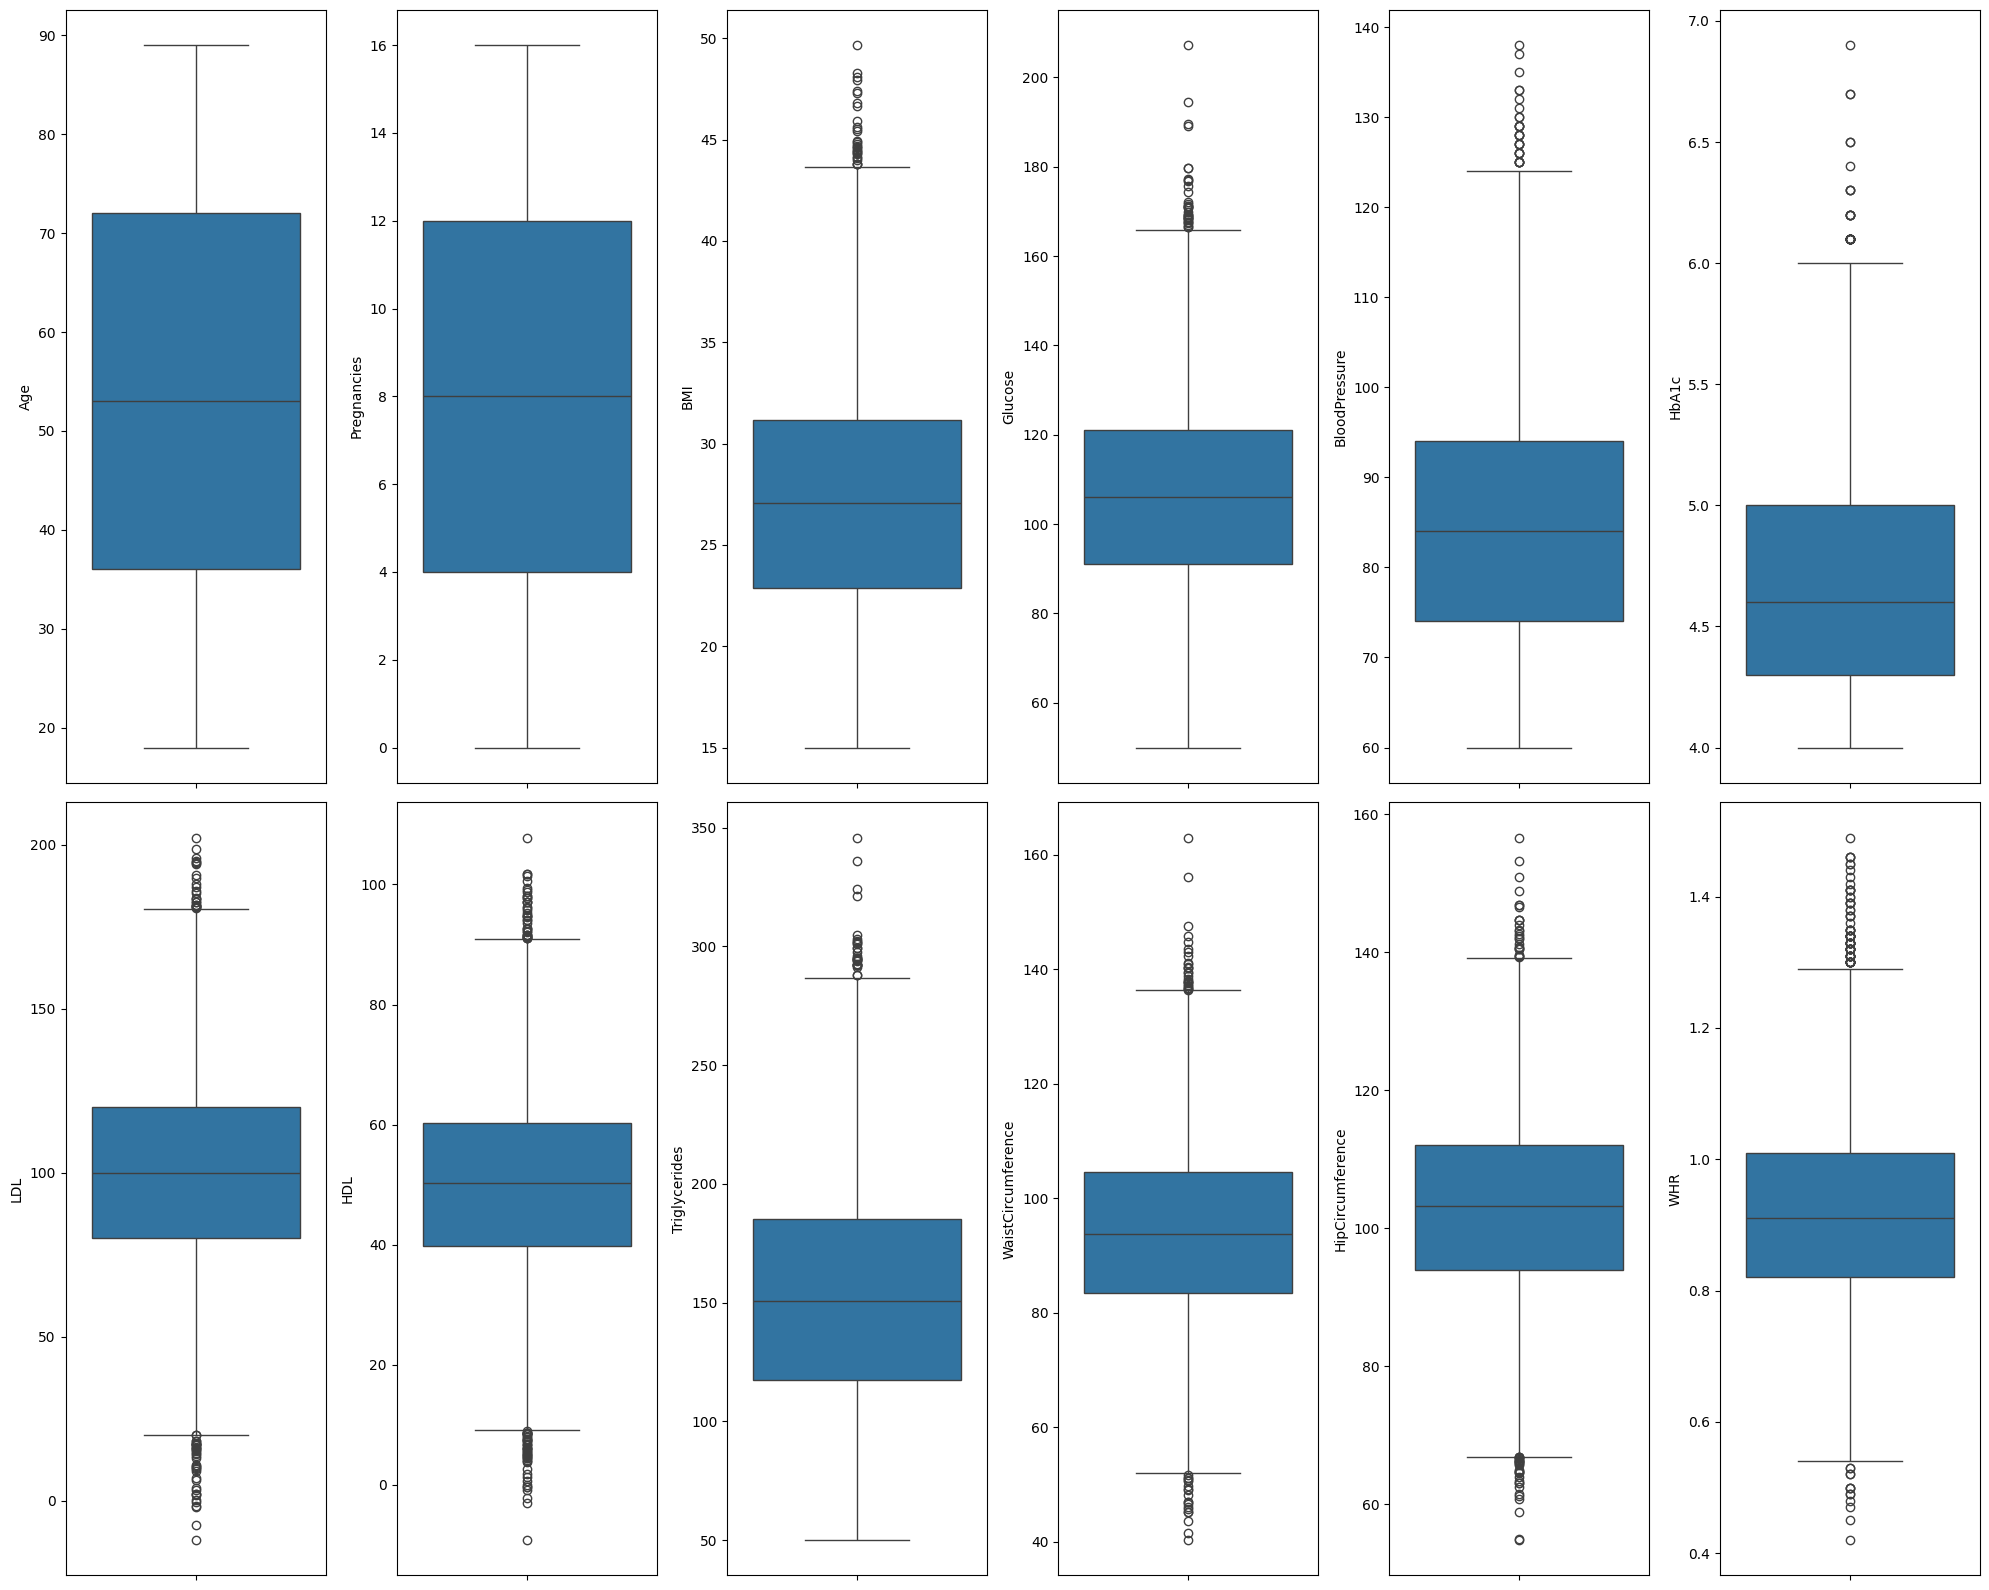

In [21]:
cols = df.columns[:12]
n = len(cols)
plt.figure(figsize=(20, 16))
for i, col in enumerate(cols, start=1):
    plt.subplot(2, 6, i)
    sns.boxplot(y=df[col])

plt.tight_layout()

Необходимо ли выполнить какую-то предобработку? Сделайте всё, что считаете нужным, всё может сказаться в дальнейшем при построении моделей.

In [21]:
# Ваш код
...

Ellipsis

## Выборка данных

В разделении данных помогает замечательна функция `train_test_split` из библиотеки `scikit-learn`. Именно этой библиотекой мы в основном будем пользоваться в дальнейшем. Напоминаю, если у вас нет библиотеки, её легко установить через `pip` даже из ячейки ноутбука.

In [22]:
# Если нужно установить библиотеку:

# !pip install scikit-learn

In [23]:
from sklearn.model_selection import train_test_split

Теперь можем использовать эту функцию для разделения данных. Функция принимает на вход два набора данных (пожаем один с признаками, другой с целевым признаком), аргумент `test_size` позволяет указать долю данных, которую нужно отделить в тестовый набор. Функция автоматически случаным образом разделит датасеты в указанном соотношении, при этом в тестовую часть попадут соответствующие строки из обоих наборов данных.

Также указывается аргумент `random_state`, он не обязателен, но рекомендуется его указывать. Это фиксация сида для генерации рандомных чисел. Таким образом, указывая одно и то же число в этом аргументе, вы получите одно и то же разбиение на выборки. Этот аргумент позволяет сделать ваши манипуляции воспроизводимыми.

Функция возвращает четыре датасета, по два для каждого из переданных, при этом в каждой паре сначала идет обучающая выборка, затем тестовая. Обратите внимание, как мы сохраняем резульатат. Здесь "x" - признаки, "y" - целевой признак.

In [24]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['Outcome'], axis=1), df['Outcome'], test_size=0.25, random_state=42)

Сравните размеры датасетов, убедитесь, что в тестовой выборке нужное нам количество данных. Сравните индексы датасетов с признаками и целевым признаком, чтобы убедиться, что они совпадают.

In [54]:
# Ваш код
display(x_train.head())
display(x_test.head())
display(y_train.head())
display(y_test.head())
display(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse
1281,35,10,33.70,138.2,73.0,4.8,95.8,66.9,166.1,125.4,116.0,1.08,0,0,0,0
5963,34,12,31.52,106.0,85.0,4.4,93.7,28.2,118.8,99.7,101.2,0.99,0,1,0,0
3997,54,4,24.60,103.1,61.0,4.8,96.5,50.0,155.7,97.3,100.0,0.97,1,1,0,0
4415,48,5,29.42,118.9,79.0,4.8,138.6,23.1,127.4,103.1,107.5,0.96,0,1,0,0
8462,88,13,29.94,114.9,94.0,4.5,85.3,63.9,231.3,105.7,88.0,1.20,0,1,0,1


,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse
5404,89,10,33.00,132.1,110.0,5.4,110.2,56.5,111.3,94.2,105.3,0.89,0,0,0,1
5857,54,14,21.17,107.5,71.0,4.5,63.9,62.5,143.1,86.4,94.5,0.91,1,0,0,0
8275,41,16,28.83,124.3,88.0,4.5,137.0,56.4,92.1,99.4,98.0,1.01,0,1,0,0
1578,48,1,34.82,106.7,85.0,4.9,169.6,3.8,246.0,137.0,114.6,1.20,0,0,0,0
6338,27,11,32.67,104.1,83.0,5.0,130.2,17.9,202.2,110.6,103.8,1.07,0,2,0,0


1281    0
5963    0
3997    1
4415    0
8462    0
Name: Outcome, dtype: int64

5404    0
5857    1
8275    0
1578    0
6338    0
Name: Outcome, dtype: int64

(7153, 16)

(2385, 16)

(7153,)

(2385,)

## kNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [27]:
knn = KNeighborsClassifier(n_neighbors=10)

In [60]:
%time
knn_model = knn.fit(x_train, y_train)

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 6.2 μs


In [61]:
%time
knn_predictions = knn.predict(x_test.values)
knn_predictions

CPU times: user 5 μs, sys: 2 μs, total: 7 μs
Wall time: 11.9 μs


/Users/admin/Desktop/СГУ/Машинное обучение/venv_0/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0, 0, 0, ..., 0, 0, 0], shape=(2385,))

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy = accuracy_score(y_test, knn_predictions)
print(f'Accuracy: {accuracy}')

Accuracy: 0.6737945492662474


Матрица ошибок

---
|           | Predicted: 0 | Predicted:1 |
|-----------|:------------:|:-----------:|
| Actual: 0 | TN           | FP          |
| Actual: 1 | FN           | TP          |

In [32]:
from sklearn.metrics import confusion_matrix

In [33]:
cm = confusion_matrix(y_test, knn_predictions)
cm

array([[1480,  102],
       [ 676,  127]])

In [64]:
y_test.value_counts()

Outcome
0    1582
1     803
Name: count, dtype: int64

Матрица ошибок хороша, но можно ли сделать её легче для восприятия? Попробуйте сделать тепловую карту.

<Axes: >

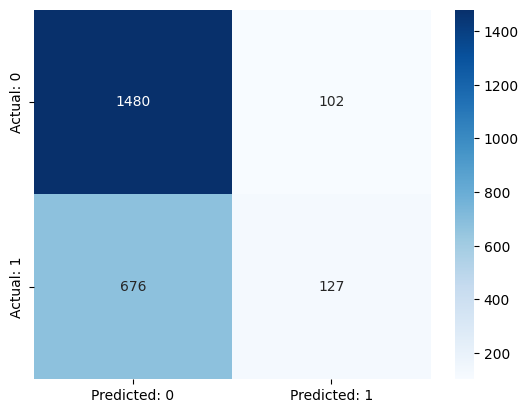

In [34]:
# Ваш код
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: 0', 'Predicted: 1'],
            yticklabels=['Actual: 0', 'Actual: 1'])

Продолжим изучение метрик. Что мы можем получить ещё из матрицы ошибок? Два важных показателя.

---

$Precision = \frac{TP}{TP+FP}$

Точность определяет, как много отрицательных ответов нашла модель, пока искала положительные. Чем больше отрицательных, тем ниже точность.

---

$Recall = \frac{TP}{TP+FN}$

Полнота выявляет, какую долю положительных среди всех ответов выделила модель. Обычно они на вес золота, и важно понимать, как хорошо модель их находит.

In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [66]:
precision = precision_score(y_test, knn_predictions)
recall = recall_score(y_test, knn_predictions)
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Precision: 0.5545851528384279
Recall: 0.1581569115815691


F1-мера - среднее гармоническое точности и полноты.

In [67]:
f1 = f1_score(y_test, knn_predictions)
print(f'F1: {f1}')

F1: 0.24612403100775193


/var/folders/sl/trjmdn1x1qqd0p90hsmrc_440000gn/T/ipykernel_5487/1478937934.py:9: RuntimeWarning: invalid value encountered in divide
  z = 2*X*Y/(X+Y)


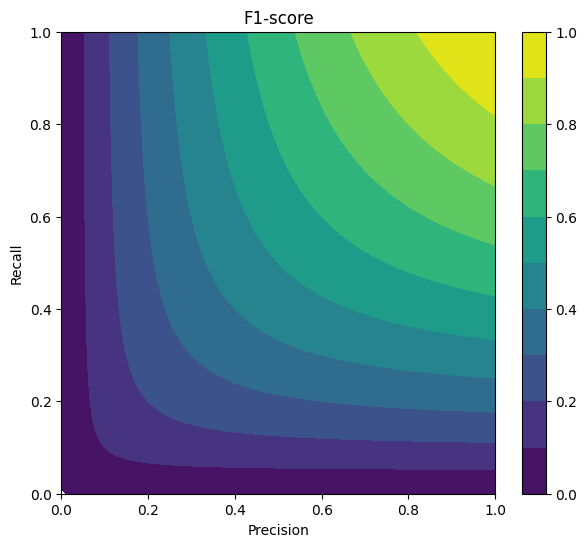

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker

x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)

X, Y = np.meshgrid(x, y)
z = 2*X*Y/(X+Y)

fig, ax = plt.subplots(figsize=(7,6))
cs = ax.contourf(X, Y, z, locator=ticker.LinearLocator())
cbar = fig.colorbar(cs)
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('F1-score');

## Нормализация

In [69]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [70]:
scaler = StandardScaler()

In [71]:
scaler.fit_transform(x_train)

array([[-0.88697085,  0.4037797 ,  1.12362248, ..., -0.73169924,
        -0.02897435, -0.81954393],
       [-0.93494042,  0.80894716,  0.75502011, ...,  0.80315257,
        -0.02897435, -0.81954393],
       [ 0.02445086, -0.81172266, -0.4150388 , ...,  0.80315257,
        -0.02897435, -0.81954393],
       ...,
       [ 0.60008563,  1.61928207, -1.95370008, ...,  0.80315257,
        -0.02897435,  1.22019084],
       [ 0.98384215, -1.01430639, -0.89185471, ...,  2.33800439,
        -0.02897435,  1.22019084],
       [ 0.69602476, -0.20397148, -0.98992323, ..., -0.73169924,
        -0.02897435,  1.22019084]], shape=(7153, 16))

In [72]:
scaler.transform(x_test)

array([[ 1.70338561,  0.4037797 ,  1.00526392, ..., -0.73169924,
        -0.02897435,  1.22019084],
       [ 0.02445086,  1.21411461, -0.99499574, ..., -0.73169924,
        -0.02897435, -0.81954393],
       [-0.59915347,  1.61928207,  0.30018507, ...,  0.80315257,
        -0.02897435, -0.81954393],
       ...,
       [-1.07884911, -0.20397148,  0.98497388, ...,  2.33800439,
        -0.02897435, -0.81954393],
       [-0.59915347, -1.62205757, -1.13026267, ..., -0.73169924,
        -0.02897435, -0.81954393],
       [ 0.07242043,  0.60636343,  1.42120971, ..., -0.73169924,
        -0.02897435, -0.81954393]], shape=(2385, 16))

In [73]:
scaler_2 = MinMaxScaler()

In [75]:
scaler_2.fit_transform(x_train)

array([[0.23943662, 0.625     , 0.56223692, ..., 0.        , 0.        ,
        0.        ],
       [0.22535211, 0.75      , 0.49669272, ..., 0.5       , 0.        ,
        0.        ],
       [0.50704225, 0.25      , 0.288635  , ..., 0.5       , 0.        ,
        0.        ],
       ...,
       [0.67605634, 1.        , 0.01503307, ..., 0.5       , 0.        ,
        1.        ],
       [0.78873239, 0.1875    , 0.20384847, ..., 1.        , 0.        ,
        1.        ],
       [0.70422535, 0.4375    , 0.1864101 , ..., 0.        , 0.        ,
        1.        ]], shape=(7153, 16))

In [76]:
scaler_2.transform(x_test)

array([[1.        , 0.625     , 0.54119062, ..., 0.        , 0.        ,
        1.        ],
       [0.50704225, 0.875     , 0.18550812, ..., 0.        , 0.        ,
        0.        ],
       [0.32394366, 1.        , 0.41581479, ..., 0.5       , 0.        ,
        0.        ],
       ...,
       [0.18309859, 0.4375    , 0.53758268, ..., 1.        , 0.        ,
        0.        ],
       [0.32394366, 0.        , 0.1614552 , ..., 0.        , 0.        ,
        0.        ],
       [0.52112676, 0.6875    , 0.61515334, ..., 0.        , 0.        ,
        0.        ]], shape=(2385, 16))

## Дисбаланс

Посмотрим на объемы данных в наших классах. Напишите код. чтобы сравнить их размеры:

In [78]:
# Ваш код
display(df['Outcome'].value_counts())
display(y_train.value_counts())
display(y_test.value_counts())

Outcome
0    6256
1    3282
Name: count, dtype: int64

Outcome
0    4674
1    2479
Name: count, dtype: int64

Outcome
0    1582
1     803
Name: count, dtype: int64

Upsampling and Downsampling

Синтез

In [131]:
df.columns

Index(['Age', 'Pregnancies', 'BMI', 'Glucose', 'BloodPressure', 'HbA1c', 'LDL',
       'HDL', 'Triglycerides', 'WaistCircumference', 'HipCircumference', 'WHR',
       'FamilyHistory', 'DietType', 'Hypertension', 'MedicationUse',
       'Outcome'],
      dtype='str')

In [150]:
x_test = x_test.drop(['FamilyHistory'], axis=1)

## Дерево решений

In [136]:
from sklearn.tree import DecisionTreeClassifier

In [144]:
clf = DecisionTreeClassifier(max_depth=8, random_state=42)

In [145]:
clf.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [151]:
pred = clf.predict(x_test)

In [152]:
accuracy_score(y_test, pred)

0.7127882599580713

In [153]:
from sklearn import tree

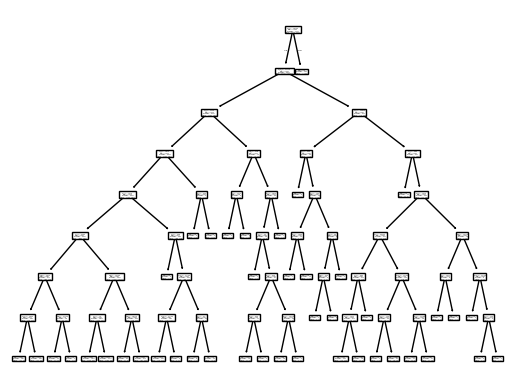

In [154]:
tree.plot_tree(clf);

## Кросс-валидация

In [129]:
from sklearn.model_selection import cross_val_score

In [130]:
cross_val_score(clf, df.drop(['Outcome'], axis=1), df['Outcome'], cv=5).mean()

np.float64(1.0)